# Workflow for the 1mM Millard's data

### Prerequisites

In [2]:
#Imports
import torch 
from torch import nn
import random
import sys, os
from numpy import genfromtxt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from lib.tools import random_ranges
from ode_dict.Millard_dicts import ode_parameters_dict, ode_parameter_ranges_dict
import numpy as np
from ode_dict.deriv_equations_Millard import ODE_residual_dict_Millard 
from lib.pinn_auxloss_f import Pinn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import jax.numpy as jnp
import pandas as pd

In [3]:
#Specifying the seed
random.seed(42)
torch.manual_seed(42)

### Loading the data

In [4]:
#Load the data
##Experimental data
data_1mM = genfromtxt(os.path.join('../data/data_1mM.csv'), delimiter=',')
data_t_1mM = data_1mM[1:, 0]

#Auxiliary data (obtained by integration here)
data_aux_1mM=[torch.tensor([12.89999655, 0.9200020244, 0.06999993881, 0.27305, 0.063, 1.035]),
              torch.tensor([0.77457781,  3.99120414,  0.85387902,  0.54487839,  0.12541807, 4.07405124])]

### Defining the inputs of the PINN

In [5]:
##Names of the variables associated with data
observables = ["GLC","ACE_env","X"] 

##Dictionaries for the data and no-data variables (and associated data)
variable_data = {"GLC": data_1mM[1:, 3], "ACE_env": data_1mM[1:, 1], "X":data_1mM[1:, 2]} 
variable_no_data  = {"ACCOA":None,"ACP":None,"ACE_cell":None}

##Time points specification
data_t = data_t_1mM

In [6]:
#List of the names of unknown parameters
parameter_names = ["v_max_AckA",
                   "v_max_Pta",
                   "v_max_glycolysis",
                   "Ki_ACE_glycolysis",
                   "Km_ACCOA_TCA_cycle",
                   "v_max_TCA_cycle",
                   "Ki_ACE_TCA_cycle",
                   "Y",
                   "v_max_acetate_exchange",
                   "Km_ACE_acetate_exchange"]

#Specifying the ranges from the dictionary
ranges = random_ranges([ode_parameters_dict[key] for key in parameter_names],scale=20)
for i,name in enumerate(parameter_names):
    if name in ode_parameter_ranges_dict:
        ranges[i]= ode_parameter_ranges_dict[name]
        
#Specifying the constants, i.e. the true values of parameters
constants_dict = ode_parameters_dict

In [7]:
# Training parameters
epoch_number = 150000

# Optimizer parameters
optimizer_type = "Adam"
optimizer_hyperparameters = {"lr":1e-4, "betas":(0.9, 0.8)}

# Scheduler parameters
scheduler_hyperparameters = {"base_lr":1e-4,
                             "max_lr":1e-4,
                             "step_size_up":100,
                             "scale_mode":"exp_range",
                             "gamma":0.999,
                             "cycle_momentum":False}

#Specifying the guiding weighting of the PINN (i.e. the weights that will multiply the balancing method output)
residual_weights=[1e-4,1e-1,1e-1,1e-14,1e-15,1e-8]

# Loss balancing method
multiple_loss_method = "prior_losses"

### Creating and training the PINN

In [8]:
#Creating PINN
pinn_cell = Pinn(ode_residual_dict=ODE_residual_dict_Millard,
                 ranges=ranges,
                 data_t=data_t,
                 variables_data=variable_data,
                 variables_no_data=variable_no_data,
                 data_aux=data_aux_1mM,
                 parameter_names=parameter_names,
                 optimizer_type=optimizer_type,
                 optimizer_hyperparameters=optimizer_hyperparameters,
                 scheduler_hyperparameters=scheduler_hyperparameters,
                 constants_dict=constants_dict,
                 #Loss balancing specification
                 multi_loss_method=multiple_loss_method,
                 residual_weights=residual_weights,
                 variable_fit_weights=None,
                 auxiliary_fit_weights=None,
                 #SoftAdapt parameters
                 soft_adapt_beta=0.1,
                 soft_adapt_t=1,
                 soft_adapt_normalize=True,
                 soft_adapt_by_type=True,
                 soft_adapt_eps=10E-8,
                 soft_adapt_warming=-1,
                 #Increments parametrisation
                 incr_residual_weight=20000,
                 increment=1E2,
                 #Prior_losses parameters
                 prior_losses_t=100,
                 #Wang parameters
                 wang_residual = True,
                 wang_t=1,
                 wang_alpha=0.9,
                 wang_epsilon=1E-8,
                 wang_warming=-1,
                 #NN parameters
                 net_hidden=7,
                 activation_function=nn.Softplus(),
                 optuna=False)

In [9]:
# Training
r2_score_overall, r2_score_per_vars, r2_score_list, pred_variables, losses, variable_fit_losses, residual_losses, aux_losses, all_learned_parameters, learning_rates = pinn_cell.train(epoch_number) #epoch_number
GLC_pred, ACE_env_pred, X_pred, ACCOA_pred, ACP_pred, ACE_cell_pred  = pred_variables

Training the neural network: 100%|███████████████████████████████████████████████████████████████████████████| 150000/150000 [10:24<00:00, 240.14it/s]


### Extracting the data and validating

Creating first a validation set for comparison between ODE model and PINN model

In [11]:
#ValidationSet – Scipy's ODE solving with the right parameters (i.e. true values)
def acetate_overflow_model(
    t,
    v_max_glycolysis=5557.64,
    Km_GLC=0.02,
    Ki_ACE_glycolysis=36.6776,
    volume=0.00177,
    v_feed=0,
    D=0,
    v_max_acetate_exchange=480034.55363364267,
    Keq_acetate_exchange=1,
    Km_ACE_acetate_exchange=33.153580532659561,
    Y=9.980425734506176e-05,
    v_max_TCA_cycle=740859.87349901034,
    Km_ACCOA_TCA_cycle=24.759179607035055,
    Ki_ACE_TCA_cycle=2.3261654310710522,
    v_max_Pta=9565521.7634551357,
    Keq_Pta=0.0281,
    Km_ACP_Pta=0.7,
    Km_P=2.6,
    Km_ACCOA_Pta=0.2,
    COA=1.22,
    P=10,
    Ki_P=2.6,
    Ki_ACP=0.2,
    Km_COA=0.029,
    v_max_AckA=336940.01763224584,
    ADP=0.606,
    ATP=2.4,
    Keq_AckA=174,
    Km_ACP_AckA=0.16,
    Km_ADP=0.5,
    Km_ATP=0.07,
    Km_ACE_AckA=7,
):
    def func(y, t):

        GLC, ACE_env, X, ACCOA, ACP, ACE_cell = [y[i] for i in range(len(y))]

        r1 = lambda V, S, Km, I, Ki : V*S/((Km+S)*(1+I/Ki))

        v_glycolysis = lambda v_max_glycolysis, GLC, Km_GLC, ACE_env, Ki_ACE_glycolysis : r1(v_max_glycolysis, GLC, Km_GLC, ACE_env, Ki_ACE_glycolysis)

        v_TCA_cycle = lambda v_max_TCA_cycle, ACCOA, Km_ACCOA_TCA_cycle, ACE_env, Ki_ACE_TCA_cycle : r1(v_max_TCA_cycle, ACCOA, Km_ACCOA_TCA_cycle, ACE_env, Ki_ACE_TCA_cycle)

        v_AckA = lambda v_max_AckA, ACP, ADP, ACE_cell, ATP, Keq_AckA, Km_ACP_AckA, Km_ADP, Km_ATP, Km_ACE_AckA : \
           v_max_AckA*(ACP*ADP-ACE_cell*ATP/Keq_AckA)/(Km_ACP_AckA*Km_ADP)/((1+ACP/Km_ACP_AckA+ACE_cell/Km_ACE_AckA)*(1+ADP/Km_ADP+ATP/Km_ATP))

        v_Pta = lambda v_max_Pta, ACCOA, P, ACP, COA, Keq_Pta, Km_ACP_Pta, Km_P, Km_ACCOA_Pta, Ki_P, Ki_ACP, Km_COA : \
           v_max_Pta*(ACCOA*P-ACP*COA/Keq_Pta)/(Km_ACCOA_Pta*Km_P)/(1+ACCOA/Km_ACCOA_Pta+P/Ki_P+ACP/Ki_ACP+COA/Km_COA+ACCOA*P/(Km_ACCOA_Pta*Km_P)+ACP*COA/(Km_ACP_Pta*Km_COA))

        v_acetate_exchange = lambda v_max_acetate_exchange, ACE_cell, ACE_env, Keq_acetate_exchange, Km_ACE_acetate_exchange : \
           v_max_acetate_exchange*(ACE_cell-ACE_env/Keq_acetate_exchange)/Km_ACE_acetate_exchange/(1+ACE_cell/Km_ACE_acetate_exchange+ACE_env/Km_ACE_acetate_exchange)

        dGLCdt = - v_glycolysis(v_max_glycolysis=v_max_glycolysis,
                            GLC=GLC,
                            Km_GLC=Km_GLC,
                            ACE_env=ACE_env,
                            Ki_ACE_glycolysis=Ki_ACE_glycolysis) \
               *X \
               *(volume) \
               +(v_feed-D*GLC)

        dACE_envdt = v_acetate_exchange(v_max_acetate_exchange=v_max_acetate_exchange,
                                    ACE_cell=ACE_cell,
                                    ACE_env=ACE_env,
                                    Keq_acetate_exchange=Keq_acetate_exchange,
                                    Km_ACE_acetate_exchange=Km_ACE_acetate_exchange) \
               *X \
               *(volume) \
               +(-D*ACE_env)

        dXdt = X \
            *v_TCA_cycle(v_max_TCA_cycle=v_max_TCA_cycle,
                         ACCOA=ACCOA,
                         Km_ACCOA_TCA_cycle=Km_ACCOA_TCA_cycle,
                         ACE_env=ACE_env,
                         Ki_ACE_TCA_cycle=Ki_ACE_TCA_cycle) \
            *Y \
            +(-D*X)

        dACCOAdt = 1.4*v_glycolysis(v_max_glycolysis=v_max_glycolysis,
                                GLC=GLC,
                                Km_GLC=Km_GLC,
                                ACE_env=ACE_env,
                                Ki_ACE_glycolysis=Ki_ACE_glycolysis) \
            - v_Pta(v_max_Pta=v_max_Pta,
                    ACCOA=ACCOA,
                    P=P,
                    ACP=ACP,
                    COA=COA,
                    Keq_Pta=Keq_Pta,
                    Km_ACP_Pta=Km_ACP_Pta,
                    Km_P=Km_P,
                    Km_ACCOA_Pta=Km_ACCOA_Pta,
                    Ki_P=Ki_P,
                    Ki_ACP=Ki_ACP,
                    Km_COA=Km_COA) \
            - v_TCA_cycle(v_max_TCA_cycle=v_max_TCA_cycle,
                          ACCOA=ACCOA,
                          Km_ACCOA_TCA_cycle=Km_ACCOA_TCA_cycle,
                          ACE_env=ACE_env,
                          Ki_ACE_TCA_cycle=Ki_ACE_TCA_cycle)

        dACPdt = v_Pta(v_max_Pta=v_max_Pta,
                   ACCOA=ACCOA,
                   P=P,
                   ACP=ACP,
                   COA=COA,
                   Keq_Pta=Keq_Pta,
                   Km_ACP_Pta=Km_ACP_Pta,
                   Km_P=Km_P,
                   Km_ACCOA_Pta=Km_ACCOA_Pta,
                   Ki_P=Ki_P,
                   Ki_ACP=Ki_ACP,
                   Km_COA=Km_COA) \
            - v_AckA(v_max_AckA=v_max_AckA,
                     ACP=ACP,
                     ADP=ADP,
                     ACE_cell=ACE_cell,
                     ATP=ATP,
                     Keq_AckA=Keq_AckA,
                     Km_ACP_AckA=Km_ACP_AckA,
                     Km_ADP=Km_ADP,
                     Km_ATP=Km_ATP,
                     Km_ACE_AckA=Km_ACE_AckA)

        dACE_celldt = v_AckA(v_max_AckA=v_max_AckA,
                         ACP=ACP,
                         ADP=ADP,
                         ACE_cell=ACE_cell,
                         ATP=ATP,
                         Keq_AckA=Keq_AckA,
                         Km_ACP_AckA=Km_ACP_AckA,
                         Km_ADP=Km_ADP,
                         Km_ATP=Km_ATP,
                         Km_ACE_AckA=Km_ACE_AckA) \
                  - v_acetate_exchange(v_max_acetate_exchange=v_max_acetate_exchange,
                                       ACE_cell=ACE_cell,
                                       ACE_env=ACE_env,
                                       Keq_acetate_exchange=Keq_acetate_exchange,
                                       Km_ACE_acetate_exchange=Km_ACE_acetate_exchange)
        return np.array([dGLCdt, dACE_envdt, dXdt, dACCOAdt, dACPdt, dACE_celldt])

    y0 = [12.89999655, 0.9200020244, 0.06999993881, 0.27305, 0.063, 1.035] #1mM
    return odeint(func, y0, t)

t = data_t_1mM
y = acetate_overflow_model(np.ravel(t))

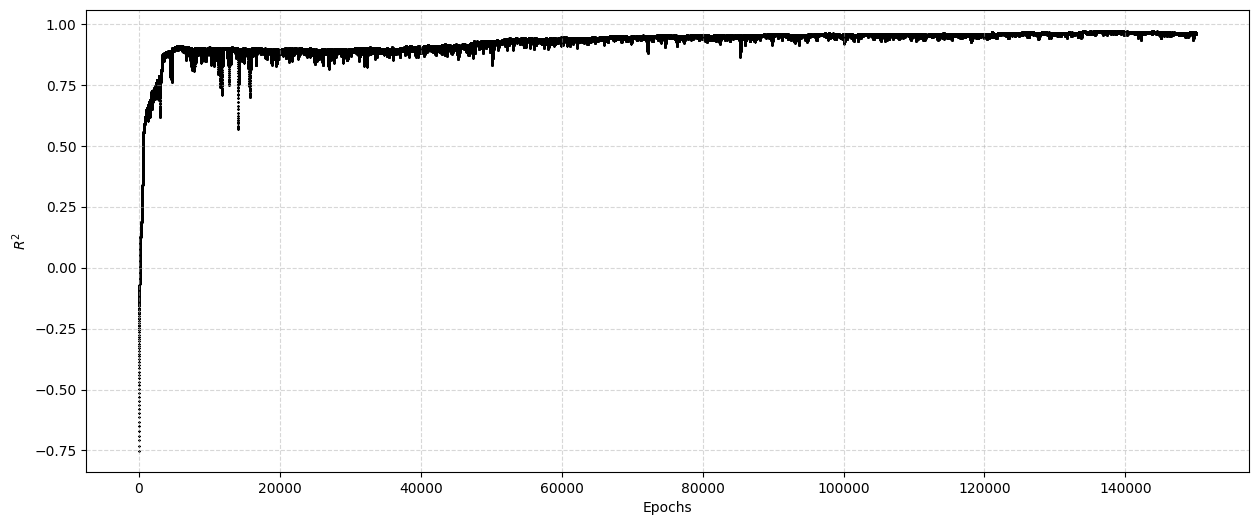

In [17]:
# R2 Epochs
plt.figure(figsize=(15,6))
plt.scatter(range(0,len(r2_score_overall)),r2_score_overall,
            s=1,
            marker="x",
            c="black",
            alpha=1.0)
plt.xlabel("Epochs")
plt.ylabel("$R^2$")
plt.title("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Observing the evolution of the learning rate

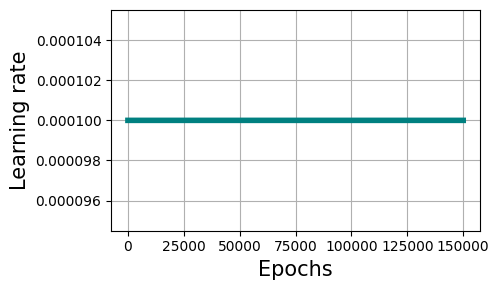

In [18]:
# Print and Plot learning rate
plt.figure(figsize=(5,3))
plt.plot(learning_rates[0:], color = 'teal',linewidth=4)
plt.grid(True)
plt.xlabel('Epochs',fontsize=15)
plt.ylabel('Learning rate',fontsize=15)

plt.tight_layout()

#To save the figure
fig_name = 'learning_rate'
plt.savefig(fig_name+'.png', format='png')

plt.show()

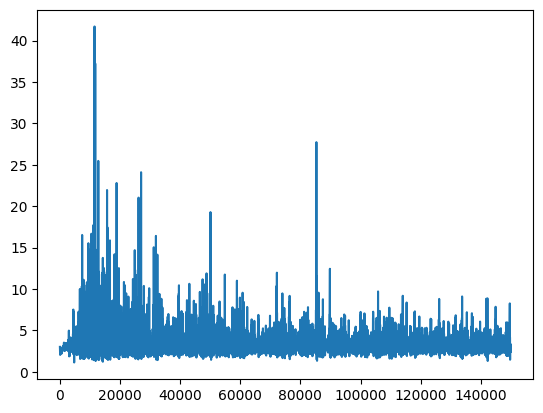

In [19]:
plt.plot(variable_fit_losses)

Loss function optimisation : graphical analysis

Loss:  6.2822


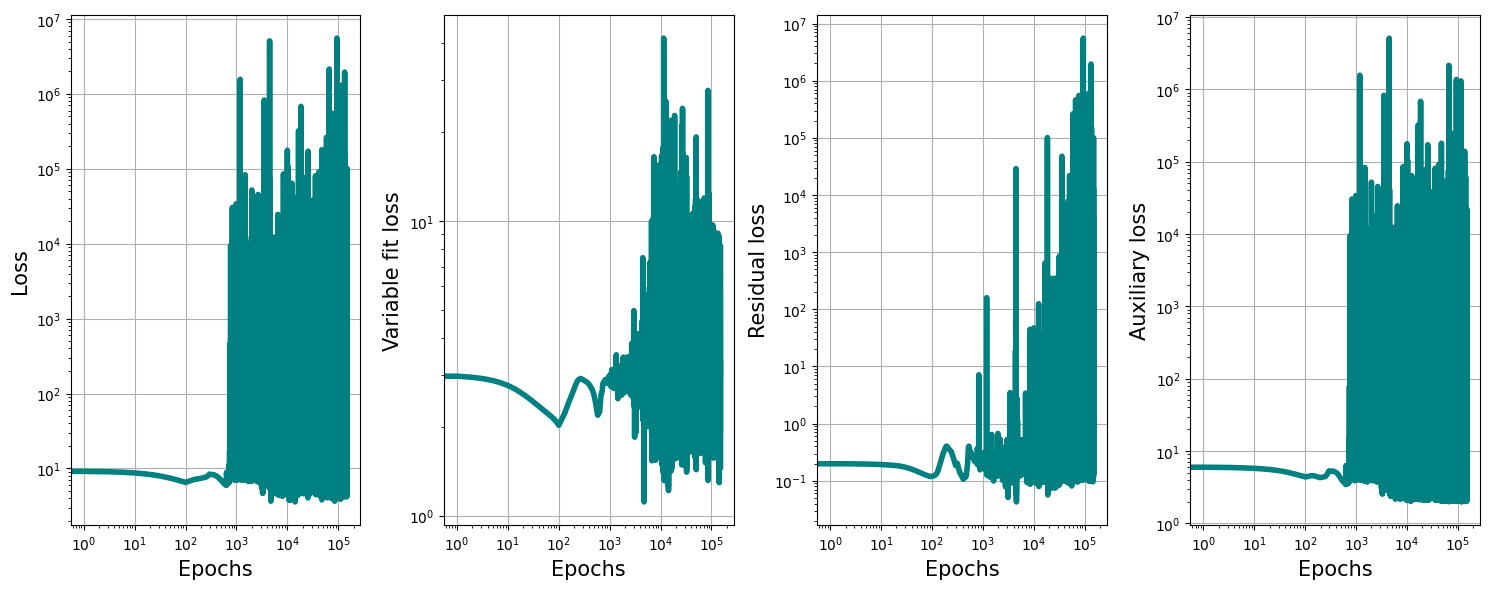

In [20]:
## Print and Plot Losses
print("Loss: ","%.5g" % losses[-1])
fig, axs = plt.subplots(1, 4, figsize=(15, 6))

axs[0].plot(losses[0:], color = 'teal',linewidth=4)
axs[0].grid(True)
axs[0].set_xlabel('Epochs',fontsize=15)
axs[0].set_ylabel('Loss',fontsize=15)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].plot(variable_fit_losses[0:], color = 'teal',linewidth=4)
axs[1].grid(True)
axs[1].set_xlabel('Epochs',fontsize=15)
axs[1].set_ylabel('Variable fit loss',fontsize=15)
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[2].plot(residual_losses[0:], color = 'teal',linewidth=4)
axs[2].grid(True)
axs[2].set_xlabel('Epochs',fontsize=15)
axs[2].set_ylabel('Residual loss',fontsize=15)
axs[2].set_xscale('log')
axs[2].set_yscale('log')


axs[3].plot(aux_losses[0:], color = 'teal',linewidth=4)
axs[3].grid(True)
axs[3].set_xlabel('Epochs',fontsize=15)
axs[3].set_ylabel('Auxiliary loss',fontsize=15)
axs[3].set_xscale('log')
axs[3].set_yscale('log')

plt.tight_layout()

#To save the figure
fig_name = 'loss_short'
plt.savefig(fig_name+'.png', format='png')

plt.show()

R2 scores evolution during optimisation

r2 : 12.291


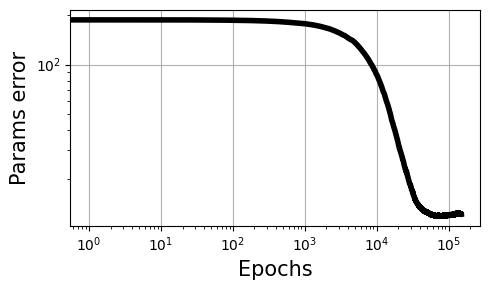

In [21]:
## Print and Plot R2
print("r2 :","%.5g" % r2_score_list[-1])

plt.figure(figsize=(5,3))
plt.plot(r2_score_list, color = 'black',linewidth=4)
plt.grid(True)
plt.xlabel('Epochs',fontsize=15)
plt.ylabel('Params error',fontsize=15)
plt.xscale('log')
plt.yscale('log')


plt.tight_layout()

#To save the figure
fig_name = 'error_short'
plt.savefig(fig_name+'.png', format='png')

plt.show()

Comparing the parameters with their true value (including the specified ranges

/tmp/ipykernel_7431/870688669.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(ranges))  # Get a colormap with as many colors as there are ranges


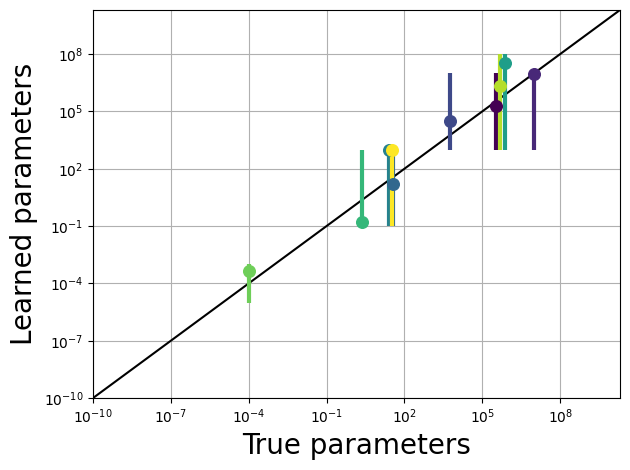

In [22]:
## Comparing parameters
learned_parameters=[pinn_cell.output_param_range(v,i).item() for (i,(k,v)) in enumerate(pinn_cell.ode_parameters.items())]
true_parameters=[ode_parameters_dict[key] for key in parameter_names]

plt.grid('true')
plt.plot([0, 2*10**10], [0, 2*10**10],color='black')
plt.scatter(true_parameters,learned_parameters)
plt.xscale('log')
plt.yscale('log')

cmap = plt.cm.get_cmap('viridis', len(ranges))  # Get a colormap with as many colors as there are ranges

# Map each range index to a color from the colormap
colors = [cmap(i) for i in range(len(ranges))]


for i, (true_val, learned_val) in enumerate(zip(true_parameters, learned_parameters)):
    plt.scatter(true_val, learned_val, s=70, color=colors[i], label=f'Range {i}' if i == 0 else "",zorder=3)

    # Also color the corresponding vertical line
    plt.vlines(x=true_val, ymin=ranges[i][0], ymax=ranges[i][1], colors=colors[i],zorder=2,linewidth=3)


min_value = min(r[0] for r in ranges)
max_value = max(r[1] for r in ranges)
plt.ylim([10**(-10),2*10**10])
plt.xlim([10**(-10),2*10**10])

plt.xlabel('True parameters',fontsize=20)
plt.ylabel('Learned parameters',fontsize=20)

plt.tight_layout()

#To save the figure
fig_name = 'params_short'
plt.savefig(fig_name+'.png', format='png')

plt.show()

Metrics values

In [23]:
## Percentage error on parameters
err=np.array([(abs(true_parameters[i]-learned_parameters[i])/true_parameters[i])*100 for i in range(len(true_parameters))])
print("percentage error", np.mean(err),"\n")

## AIC
AIC = 2*(20+7*20+20)+2*(losses[-1]) #Formula to adjust on the number of parameters
print("AIC",AIC,"\n")

## R2_scores
from sklearn.metrics import r2_score
R2_scores_train_data=[r2_score(data_1mM.T[3,1:],GLC_pred.detach().numpy()),r2_score(data_1mM.T[1,1:],ACE_env_pred.detach().numpy()),
           r2_score(data_1mM.T[2,1:],X_pred.detach().numpy())]
print("R2_scores_train_data",R2_scores_train_data,"\n")

GLC_gene,ACE_env_gene,X_gene,ACCOA_gene,ACP_gene,ACE_cell_gene=y.T
R2_scores_gene_data=[r2_score(GLC_gene,GLC_pred.detach().numpy()),r2_score(ACE_env_gene,ACE_env_pred.detach().numpy()),
           r2_score(X_gene,X_pred.detach().numpy()), r2_score(ACCOA_gene,ACCOA_pred.detach().numpy()),
           r2_score(ACP_gene,ACP_pred.detach().numpy()), r2_score(ACE_cell_gene,ACE_cell_pred.detach().numpy())]
print("R2_scores_gene_data",R2_scores_gene_data,"\n")

R2_scores_gene_vs_data=[r2_score(data_1mM.T[3,1:],GLC_gene),r2_score(data_1mM.T[1,1:],ACE_env_gene),
           r2_score(data_1mM.T[2,1:],X_gene)]
print("R2_scores_gene_vs_data",R2_scores_gene_vs_data,"\n")

percentage error 1229.0673039023654 

AIC 372.5643630809426 

R2_scores_train_data [0.9667380530772429, 0.995640033468589, 0.9127717917893916] 

R2_scores_gene_data [0.952470368888479, 0.9663802012050104, 0.9001019188571774, 0.7185626514299457, 0.6591034481389835, 0.7355557152912158] 

R2_scores_gene_vs_data [0.992740291782601, 0.965973994464217, 0.9866590730418466] 



Plotting the predictions of the PINN model (_pred), the ODE model predictions (_gene) and the measured values (_data)

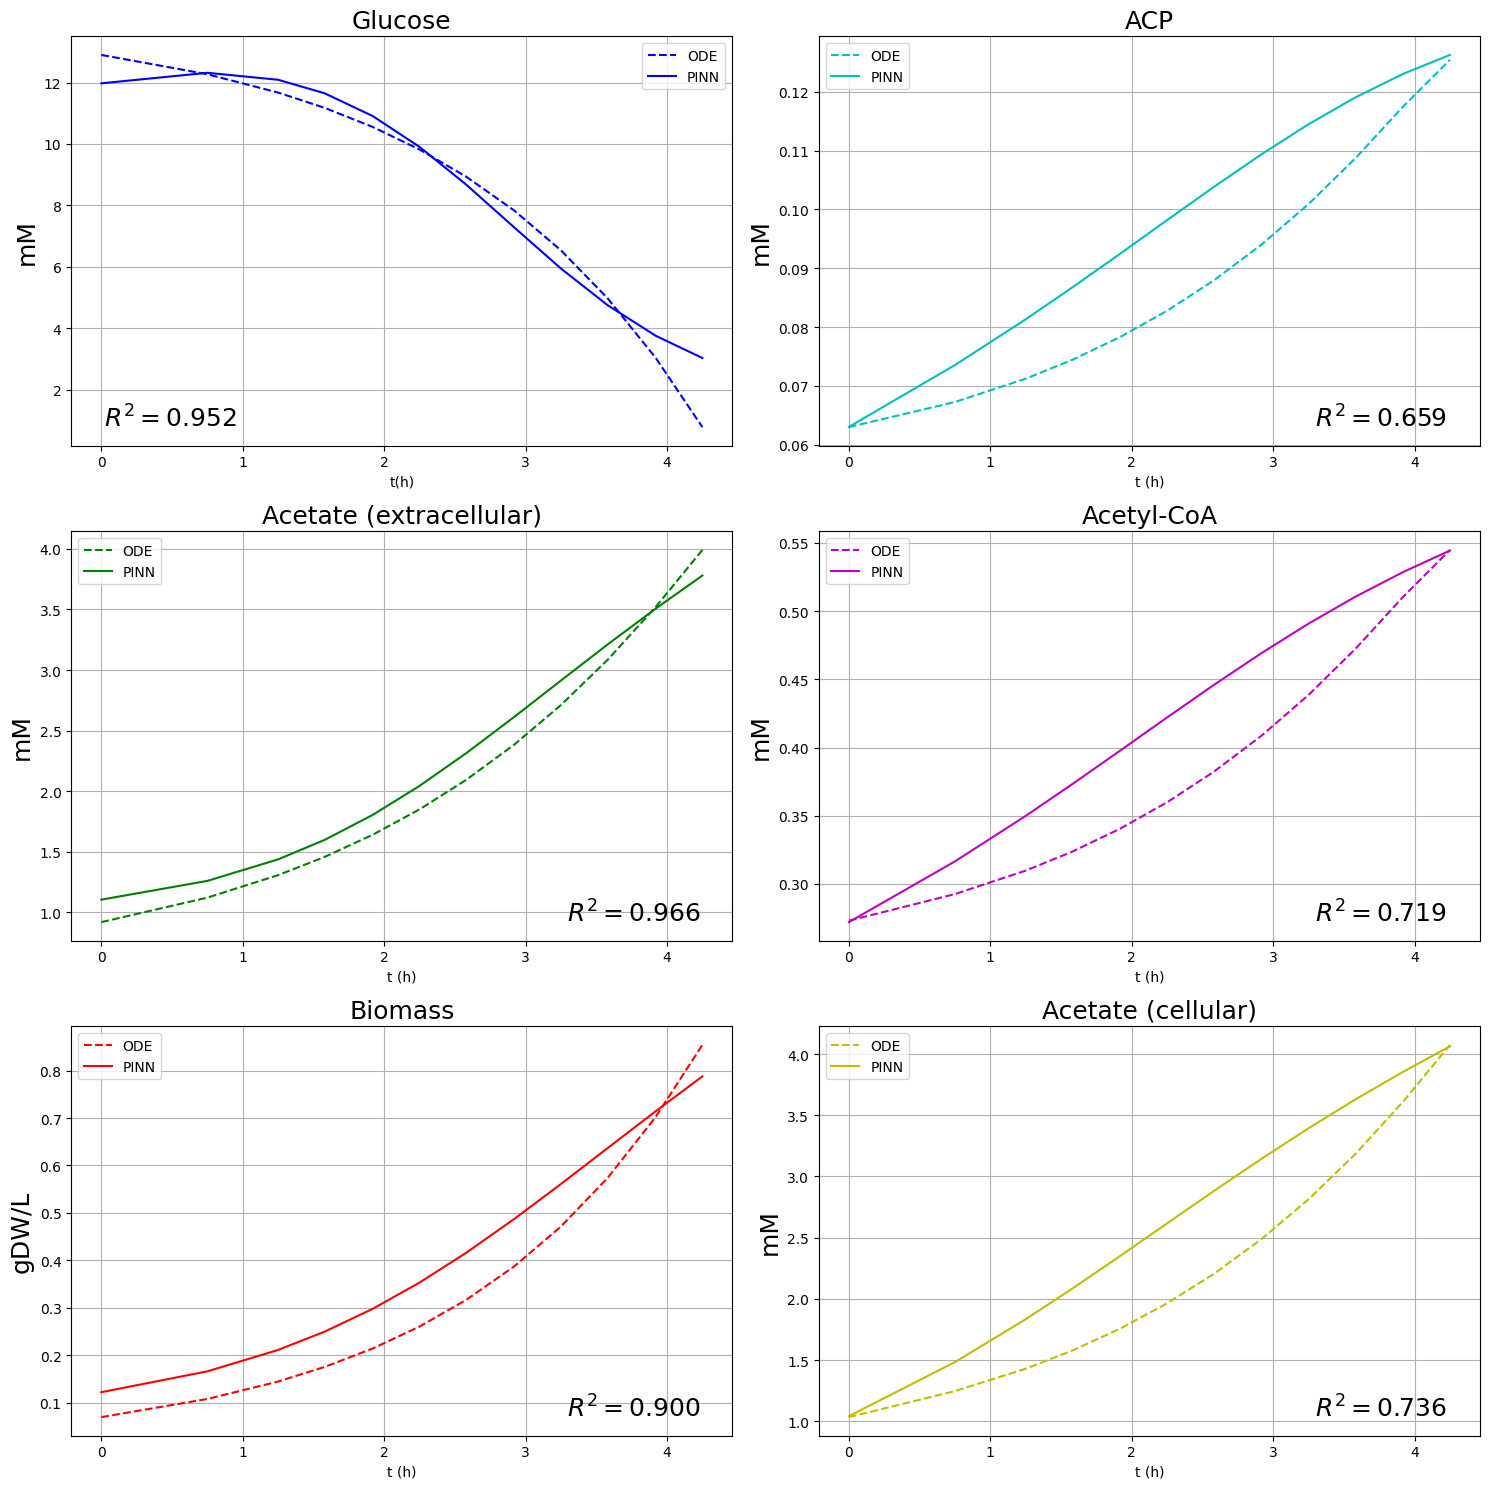

In [36]:
## Plot the predicted variables
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

fontsize_val = 18

axs[0,0].plot(t, GLC_gene, linestyle='dashed', label='ODE', color='b')
axs[0,0].plot(data_t, GLC_pred.detach().numpy(), label='PINN', color='b')
#axs[0,0].plot(data_t_1mM, data_1mM[1:, 3], 'o', label='GLC_data', color='b')
axs[0,0].text(
    0.05, 0.1, f"$R^2 = {r2_score(GLC_gene,GLC_pred.detach().numpy()):.3f}$", 
    transform=axs[0,0].transAxes, 
    fontsize=fontsize_val,
    verticalalignment='top',
)
axs[0,0].set_title('Glucose', fontsize = fontsize_val)
axs[0,0].set_xlabel('t(h)')
axs[0,0].set_ylabel('mM', fontsize = fontsize_val)
axs[0,0].legend()
axs[0,0].grid(True)



axs[1,0].plot(t, ACE_env_gene, linestyle='dashed', label='ODE', color='g')
axs[1,0].plot(data_t, ACE_env_pred.detach().numpy(), label='PINN', color='g')
#axs[0,1].plot(data_t_1mM, data_1mM[1:, 1], 'o', label='ACE_env_data', color='g')
axs[1,0].text(
    0.75, 0.1, f"$R^2 = {r2_score(ACE_env_gene,ACE_env_pred.detach().numpy()):.3f}$", 
    transform=axs[1,0].transAxes,
    fontsize = fontsize_val,
    verticalalignment='top',
)
axs[1,0].set_title('Acetate (extracellular)', fontsize = fontsize_val)
axs[1,0].set_xlabel('t (h)')
axs[1,0].set_ylabel('mM', fontsize = fontsize_val)
axs[1,0].legend()
axs[1,0].grid(True)



axs[2,0].plot(t, X_gene, linestyle='dashed', label='ODE', color='r')
axs[2,0].plot(data_t, X_pred.detach().numpy(), label='PINN', color='r')
#axs[0,2].plot(data_t_1mM, data_1mM[1:, 2], 'o',label='X_data', color='r')
axs[2,0].text(
    0.75, 0.1, f"$R^2 = {r2_score(X_gene,X_pred.detach().numpy()):.3f}$", 
    transform=axs[2,0].transAxes,
    fontsize = fontsize_val,
    verticalalignment='top',
)
axs[2,0].set_title('Biomass', fontsize = fontsize_val)
axs[2,0].set_xlabel('t (h)')
axs[2,0].set_ylabel('gDW/L', fontsize = fontsize_val)
axs[2,0].legend()
axs[2,0].grid(True)

axs[1,1].plot(t, ACCOA_gene, linestyle='dashed', label='ODE', color='m')
axs[1,1].plot(data_t, ACCOA_pred.detach().numpy(), label='PINN', color='m')
axs[1,1].text(
    0.75, 0.1, f"$R^2 = {r2_score(ACCOA_gene,ACCOA_pred.detach().numpy()):.3f}$", 
    transform=axs[1,1].transAxes, 
    fontsize = fontsize_val,
    verticalalignment='top',
)
axs[1,1].set_title('Acetyl-CoA', fontsize = fontsize_val)
axs[1,1].set_xlabel('t (h)')
axs[1,1].set_ylabel('mM', fontsize = fontsize_val)
axs[1,1].legend()
axs[1,1].grid(True)

axs[0,1].plot(t, ACP_gene, linestyle='dashed', label='ODE', color='c')
axs[0,1].plot(data_t, ACP_pred.detach().numpy(), label='PINN', color='c')
axs[0,1].text(
    0.75, 0.1, f"$R^2 = {r2_score(ACP_gene,ACP_pred.detach().numpy()):.3f}$", 
    transform=axs[0,1].transAxes,
    fontsize = fontsize_val,
    verticalalignment='top',
)
axs[0,1].set_title('ACP', fontsize = fontsize_val)
axs[0,1].set_xlabel('t (h)')
axs[0,1].set_ylabel('mM', fontsize = fontsize_val)
axs[0,1].legend()
axs[0,1].grid(True)

axs[2,1].plot(t, ACE_cell_gene, linestyle='dashed', label='ODE', color='y')
axs[2,1].plot(data_t, ACE_cell_pred.detach().numpy(), label='PINN', color='y')
axs[2,1].text(
    0.75, 0.1, f"$R^2 = {r2_score(ACE_cell_gene,ACE_cell_pred.detach().numpy()):.3f}$", 
    transform=axs[2,1].transAxes,
    fontsize = fontsize_val,
    verticalalignment='top',
)
axs[2,1].set_title('Acetate (cellular)', fontsize = fontsize_val)
axs[2,1].set_xlabel('t (h)')
axs[2,1].set_ylabel('mM', fontsize = fontsize_val)
axs[2,1].legend()
axs[2,1].grid(True)

plt.tight_layout()

fig_name = 'prediction_plot'
plt.savefig(fig_name+'.png', format='png')

plt.show()

Plotting the solving with the parameter's values as estimated by the PINN

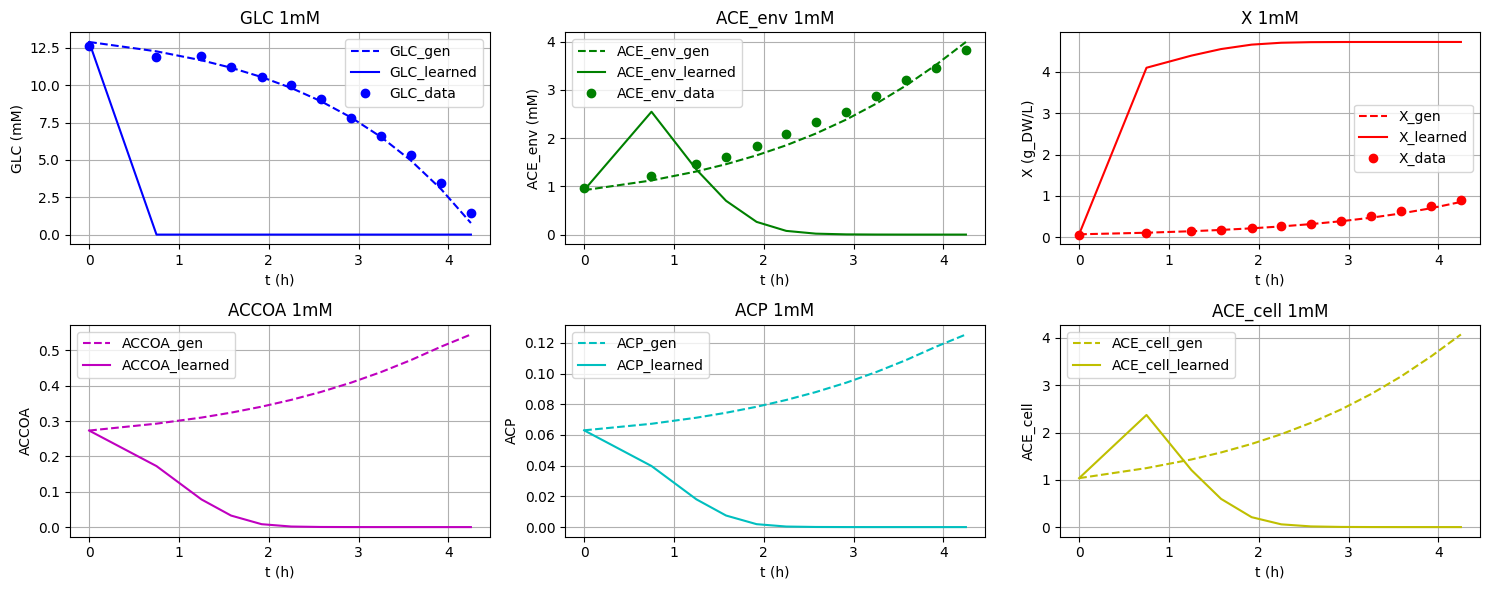

In [26]:
## Integrate with guessed parameters
from scipy.integrate import solve_ivp
from ode_dict.deriv_equations_Millard import deriv_Millard #ode_equation.

# Integrate the Millard's model equations over the time grid
learned = ode_parameters_dict.copy()
learned = learned | dict(zip(parameter_names, learned_parameters))

# initial conditions
y_1_0 = [12.89999655, 0.9200020244, 0.06999993881, 0.27305, 0.063, 1.035] #1mM

net_res = solve_ivp(fun=deriv_Millard,
                t_span=(0,4.25),
                y0=y_1_0,
                method='LSODA',
                args=(learned,),
                # args=(new_ode_parameters,),
                t_eval=data_t,
                dense_output=True)

GLC_learned, ACE_env_learned, X_learned, ACCOA_learned, ACP_learned, ACE_cell_learned = net_res.y

from lib.tools import ssr_error
from ode_dict.Millard_dicts import variable_standard_deviations_dict

# Plot the solved variables
fig, axs = plt.subplots(2, 3, figsize=(15, 6))

axs[0,0].plot(t, GLC_gene, linestyle='dashed', label='GLC_gen', color='b')
axs[0,0].plot(net_res.t, GLC_learned, label='GLC_learned', color='b')
axs[0,0].plot(data_1mM[1:, 0], data_1mM[1:, 3], 'o', label='GLC_data', color='b')
axs[0,0].set_title('GLC 1mM')
axs[0,0].set_xlabel('t (h)')
axs[0,0].set_ylabel('GLC (mM)')
axs[0,0].legend()
axs[0,0].grid(True)

axs[0,1].plot(t, ACE_env_gene, linestyle='dashed', label='ACE_env_gen', color='g')
axs[0,1].plot(net_res.t, ACE_env_learned, label='ACE_env_learned', color='g')
axs[0,1].plot(data_1mM[1:, 0], data_1mM[1:, 1], 'o', label='ACE_env_data', color='g')
axs[0,1].set_title('ACE_env 1mM')
axs[0,1].set_xlabel('t (h)')
axs[0,1].set_ylabel('ACE_env (mM)')
axs[0,1].legend()
axs[0,1].grid(True)

axs[0,2].plot(t, X_gene, linestyle='dashed', label='X_gen', color='r')
axs[0,2].plot(net_res.t, X_learned,label='X_learned', color='r')
axs[0,2].plot(data_1mM[1:, 0], data_1mM[1:, 2], 'o',label='X_data', color='r')
axs[0,2].set_title('X 1mM')
axs[0,2].set_xlabel('t (h)')
axs[0,2].set_ylabel('X (g_DW/L)')
axs[0,2].legend()
axs[0,2].grid(True)

axs[1,0].plot(t, ACCOA_gene, linestyle='dashed', label='ACCOA_gen', color='m')
axs[1,0].plot(net_res.t, ACCOA_learned, label='ACCOA_learned', color='m')
axs[1,0].set_title('ACCOA 1mM')
axs[1,0].set_xlabel('t (h)')
axs[1,0].set_ylabel('ACCOA')
axs[1,0].legend()
axs[1,0].grid(True)

axs[1,1].plot(t, ACP_gene, linestyle='dashed', label='ACP_gen', color='c')
axs[1,1].plot(net_res.t, ACP_learned, label='ACP_learned', color='c')
axs[1,1].set_title('ACP 1mM')
axs[1,1].set_xlabel('t (h)')
axs[1,1].set_ylabel('ACP')
axs[1,1].legend()
axs[1,1].grid(True)

axs[1,2].plot(t, ACE_cell_gene, linestyle='dashed', label='ACE_cell_gen', color='y')
axs[1,2].plot(net_res.t, ACE_cell_learned, label='ACE_cell_learned', color='y')
axs[1,2].set_title('ACE_cell 1mM')
axs[1,2].set_xlabel('t (h)')
axs[1,2].set_ylabel('ACE_cell')
axs[1,2].legend()
axs[1,2].grid(True)

plt.tight_layout()

fig_name = 'predicted_variables'
plt.savefig(fig_name+'.png', format='png')

plt.show()

Printing the metrics for the ODE model obtained that way

In [27]:
## Values of parameters
variable_res = {"GLC":GLC_learned,
                "ACE_env":ACE_env_learned,
                "X":X_learned,
                "ACCOA":ACCOA_learned,
                "ACP":ACP_learned,
                "ACE_cell":ACE_cell_learned}
error = ssr_error(standard_deviations_dict=variable_standard_deviations_dict, observables=observables, variable_data=variable_data, variable_res=variable_res)
print("Sum of squared residuals error: " + str(error)+" \n")

## R2 scores
R2_scores_vs_data=[r2_score(data_1mM.T[3,1:],GLC_learned),r2_score(data_1mM.T[1,1:],ACE_env_learned),
           r2_score(data_1mM.T[2,1:],X_learned)]
print("R2_scores_vs_data",R2_scores_vs_data,"\n")

R2_scores_gene_vs_learned=[r2_score(GLC_gene,GLC_learned),r2_score(ACE_env_gene,ACE_env_learned),
           r2_score(X_gene,X_learned), r2_score(ACCOA_gene,ACCOA_learned),
           r2_score(ACP_gene,ACP_learned), r2_score(ACE_cell_gene,ACE_cell_learned)]
print("R2_scores_gene_vs_learned",R2_scores_gene_vs_learned,"\n")

Sum of squared residuals error: 101826.91970043916 

R2_scores_vs_data [-4.8619858523080834, -6.12758044188912, -238.32333639827013] 

R2_scores_gene_vs_learned [-4.136859132065288, -4.916589797578957, -289.42907918630453, -18.651080073713516, -18.633972441272856, -5.475130366377536] 



In [28]:
# Print and compare parameters
from lib.tools import param_error_percentages #lib.

print("Learned parameters :")
for i in range(len(learned_parameters)):
    print(parameter_names[i], ":", learned_parameters[i])

print("\nTrue parameters :")
for i in range(len(learned_parameters)):
    print(parameter_names[i], ":", true_parameters[i])

print("\nParameters errors :")
for i in range(len(learned_parameters)):
    print(parameter_names[i], ":", param_error_percentages(true_parameters,learned_parameters)[i])

Learned parameters :
v_max_AckA : 188564.21875
v_max_Pta : 8617765.0
v_max_glycolysis : 29703.91796875
Ki_ACE_glycolysis : 16.06678581237793
Km_ACCOA_TCA_cycle : 936.233154296875
v_max_TCA_cycle : 33433506.0
Ki_ACE_TCA_cycle : 0.1535196304321289
Y : 0.00043079021270386875
v_max_acetate_exchange : 2005287.5
Km_ACE_acetate_exchange : 997.6361083984375

True parameters :
v_max_AckA : 336940.01763224584
v_max_Pta : 9565521.763455136
v_max_glycolysis : 5557.64
Ki_ACE_glycolysis : 36.6776
Km_ACCOA_TCA_cycle : 24.759179607035055
v_max_TCA_cycle : 740859.8734990103
Ki_ACE_TCA_cycle : 2.3261654310710522
Y : 9.980425734506176e-05
v_max_acetate_exchange : 480034.5536336427
Km_ACE_acetate_exchange : 33.15358053265956

Parameters errors :
v_max_AckA : 0.4403626494855563
v_max_Pta : 0.09908050882033634
v_max_glycolysis : 4.344699902971405
Ki_ACE_glycolysis : 0.5619455522613821
Km_ACCOA_TCA_cycle : 36.813577394577905
v_max_TCA_cycle : 44.12797520278261
Ki_ACE_TCA_cycle : 0.9340031330611586
Y : 3.3163

Saving all the elements

In [29]:
#Saving all elements
R2_Scores=pd.DataFrame({"R2_scores_train_data" : R2_scores_train_data+[jnp.nan,jnp.nan,jnp.nan],
                        "R2_scores_gene_data": R2_scores_gene_data,
                        "R2_scores_gene_vs_data": R2_scores_gene_vs_data+[jnp.nan,jnp.nan,jnp.nan],
                        "R2_scores_vs_data":R2_scores_vs_data+[jnp.nan,jnp.nan,jnp.nan],
                        "R2_scores_gene_vs_learned":R2_scores_gene_vs_learned,
                        })
R2_Scores.to_csv("R2_Scores.csv")

hyperparameters = pd.DataFrame({
    "epochs":[epoch_number],
    "optimizer":[str(optimizer_type)],
    "optimizer_hyperparameters":[str(optimizer_hyperparameters)],
    "scheduler":[str(scheduler_hyperparameters)],
    "multiple_loss_method":[multiple_loss_method],
    "ssr_error":[error],
    "parameter_names": [str(parameter_names)],
    "soft_adapt_beta":[pinn_cell.soft_adapt_beta],
    "soft_adapt_t":[pinn_cell.soft_adapt_t],
    "residual_weights":[str(pinn_cell.residual_weights)],
    "variable_fit_weights":[str(pinn_cell.variable_fit_weights)],
    "prior_losses_t":[pinn_cell.prior_losses_t],
})
hyperparameters.to_csv('hyperparams.csv')

metrics = pd.DataFrame({"AIC": [AIC],
                        "percentage error": [np.mean(err)],
                        "last_loss":[losses[-1]],
                        })
metrics.to_csv('metrics.csv')

parameters=pd.DataFrame({"names":parameter_names,
                        "learned_vals": learned_parameters,
                         "True_vals":true_parameters,
                         "parameters_error": param_error_percentages(true_parameters,learned_parameters),
                         })
parameters.to_csv('params.csv')

predictions=pd.DataFrame({"GLC_gene":GLC_gene,
                          "GLC_pred":GLC_pred.detach().numpy(),
                          "ACE_env_gene":ACE_env_gene,
                          "ACE_env_pred":ACE_env_pred.detach().numpy(),
                          "X_gene":X_gene,
                          "X_pred":X_pred.detach().numpy(),
                          "ACCOA_gene":ACCOA_gene,
                          "ACCOA_pred":ACCOA_pred.detach().numpy(),
                          "ACP_gene":ACP_gene,
                          "ACP_pred":ACP_pred.detach().numpy(),
                          "ACE_cell_gene":ACE_cell_gene,
                          "ACE_cell_pred":ACE_cell_pred.detach().numpy()})

predictions.to_csv('predictions.csv')